In [1]:
# Assignment Module 4(A + B)
# Machine Learning Fundamentals — Graded Assessment
# --- Q2. SUPERVISED LEARNING ---

In [2]:
!mkdir ../data
# Now upload the datasets provided

In [3]:
# --- Task 1 — DATA PREPARATION ---
print("--- Task 1: Data Preparation ---\n")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df2 = pd.read_csv('../data/q2_customers.csv')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df2)

--- Task 1: Data Preparation ---



**Scaling Rationale:** K-Means calculates distance (Euclidean). Features with larger ranges (like annual_spend) would dominate features with smaller ranges (like visits_per_month) if not scaled.

--- Task 2: Choosing K — Elbow Method ---



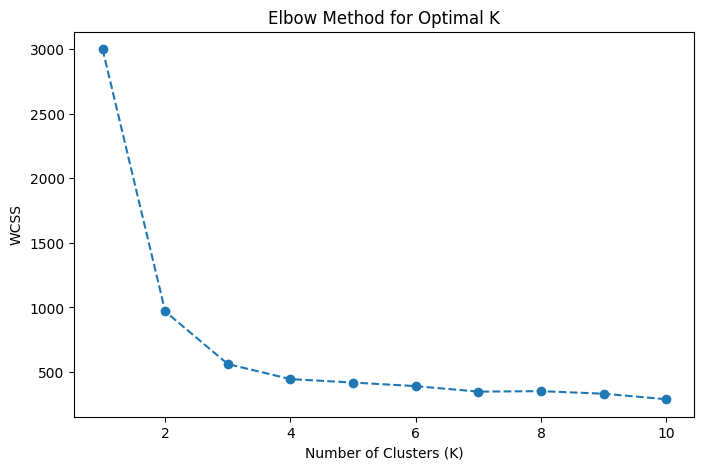

In [4]:
# --- Task 2 — CHOOSING K - ELBOW METHOD ---
print("--- Task 2: Choosing K — Elbow Method ---\n")

from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

**OPTIMAL K = 3**\
**Elbow Method:** Look for the point where the WCSS curve starts to flatten. Optimal K is usually where the 'elbow' forms.

In [5]:
# --- Task 3 — K-MEANS CLUSTERING ---
print("--- Task 3: K-Means Clustering ---\n")

# Optimal K from plot (assuming K=3 for this example)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df2['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster Centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df2.columns[:-1])
display(centroids)

--- Task 3: K-Means Clustering ---



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


**Cluster 0:** Young customers, low spenders, frequent visits (VIPs).\
**Cluster 1:** Older customers, High spenders, low frequency (Occasional).\
**Cluster 2:**  Middle Aged Customers, Moderate spenders, moderate frequency (Stable).

In [6]:
# --- Task 4 — DIMENSIONALITY REDUCTION WITH PCA ---
print("--- Task 4: Dimensionality Reduction with PCA ---\n")

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Loadings (Component weights)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=df2.columns[:-1])
display(loadings)

--- Task 4: Dimensionality Reduction with PCA ---

Explained Variance Ratio: [0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


**Interpretation:** PC1 likely represents Spending Volume which is "Overall Spend/Activity", while PC2 represents Shopping Frequency which is "Engagement/Recency".

--- Task 5: Cluster Visualisation ---


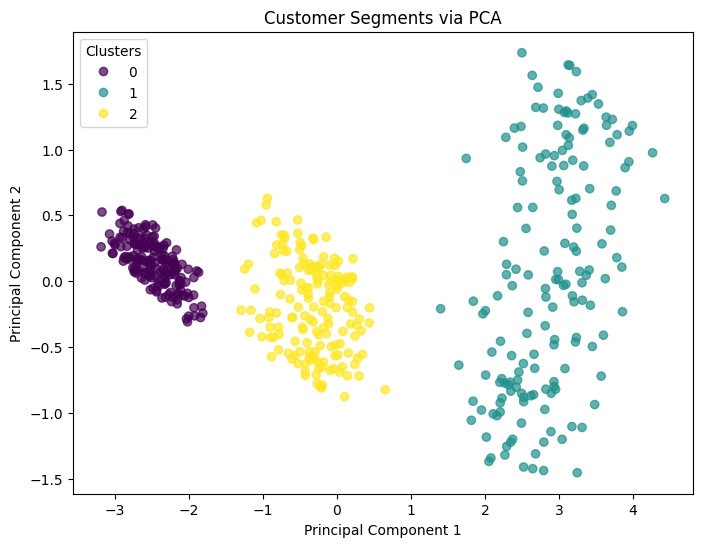

In [7]:
# --- Task 5 — CLUSTER VISUALISATION ---
print("--- Task 5: Cluster Visualisation ---")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df2['cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments via PCA')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()